In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1=pd.read_csv("/content/store.csv")
df1.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
df2=pd.read_csv("/content/train (1).csv",parse_dates=["Date"])
df2.head()

/tmp/ipykernel_12435/476817429.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df2=pd.read_csv("/content/train (1).csv",parse_dates=["Date"])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
df=pd.merge(df1,df2,on="Store",how="inner")

In [ ]:
df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,5,2015-07-31,5263,555,1,1,0,1
1,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,4,2015-07-30,5020,546,1,1,0,1
2,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,3,2015-07-29,4782,523,1,1,0,1
3,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2,2015-07-28,5011,560,1,1,0,1
4,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2015-07-27,6102,612,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1115,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec",6,2013-01-05,4771,339,1,0,0,1
1017205,1115,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec",5,2013-01-04,4540,326,1,0,0,1
1017206,1115,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec",4,2013-01-03,4297,300,1,0,0,1
1017207,1115,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec",3,2013-01-02,3697,305,1,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   StoreType                  1017209 non-null  object        
 2   Assortment                 1017209 non-null  object        
 3   CompetitionDistance        1014567 non-null  float64       
 4   CompetitionOpenSinceMonth  693861 non-null   float64       
 5   CompetitionOpenSinceYear   693861 non-null   float64       
 6   Promo2                     1017209 non-null  int64         
 7   Promo2SinceWeek            509178 non-null   float64       
 8   Promo2SinceYear            509178 non-null   float64       
 9   PromoInterval              509178 non-null   object        
 10  DayOfWeek                  1017209 non-null  int64         
 11  Date                       1017209 no

**Sales according to the store type**

In [ ]:
store=df.groupby("StoreType")["Sales"].sum()

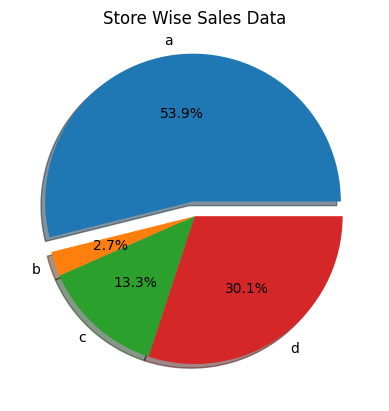

In [ ]:
a=store.index
b=store.values
ex=[0.1,0.0,0.0,0.0]
plt.pie(b,labels=a,autopct="%1.1f%%",shadow=True,explode=ex)
plt.title("Store Wise Sales Data")
plt.show()

**Sales according to the year and month wise**

In [ ]:
df["Date"]=pd.to_datetime(df["Date"],format="%y-%m-%d")
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month

In [ ]:
df["Year"].unique()

array([2015, 2014, 2013], dtype=int32)

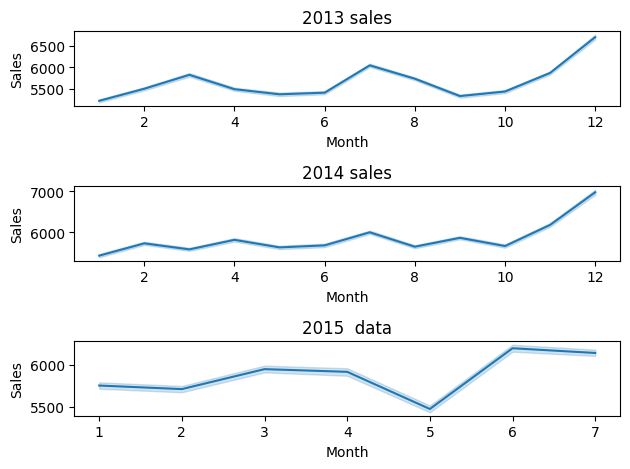

In [ ]:
plt.subplot(3,1,1)
r=df[df["Year"]==2013]
sns.lineplot(data=r,x="Month",y="Sales")
plt.title("2013 sales")
plt.subplot(3,1,2)
s=df[df["Year"]==2014]
sns.lineplot(data=s,x="Month",y="Sales")
plt.title("2014 sales")
plt.subplot(3,1,3)
t=df[df["Year"]==2015]
sns.lineplot(data=t,x="Month",y="Sales")
plt.title("2015  data")
plt.tight_layout()
plt.show()



**sales behalf of competation distance**

In [ ]:
df["CompetitionDistance"].fillna(method="ffill",inplace=True)

/tmp/ipykernel_12435/3656453100.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CompetitionDistance"].fillna(method="ffill",inplace=True)
/tmp/ipykernel_12435/3656453100.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["CompetitionDistance"].fillna(method="ffill",inplace=True)


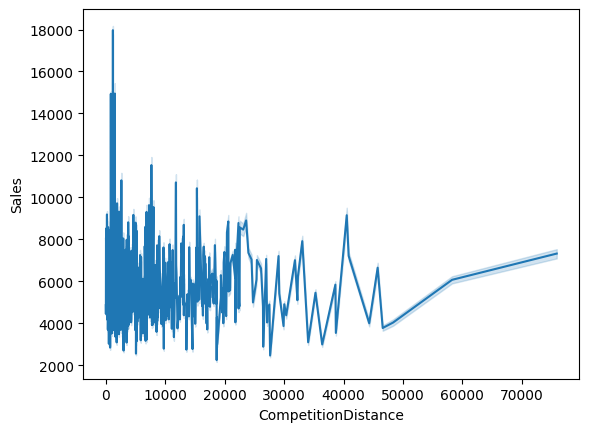

In [ ]:
sns.lineplot(data=df,x="CompetitionDistance",y="Sales")
plt.show()

**How different on sales during holiday and non-holiday**


In [ ]:
df.groupby("StateHoliday")["Sales"].sum()

,Sales
StateHoliday,
0,751505326
0,5113659442
a,5890305
b,1433744
c,691806


In [ ]:
df["StateHoliday"].replace([0,"0"],"No Holiday",inplace=True)
df["SchoolHoliday"].replace([0,1],["No Holiday","Holiday"],inplace=True)

/tmp/ipykernel_12435/319428331.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["SchoolHoliday"].replace([0,1],["No Holiday","Holiday"],inplace=True)


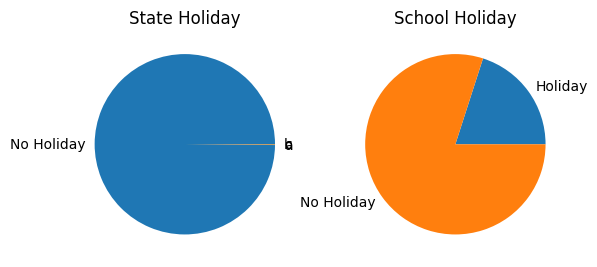

In [ ]:
plt.subplot(1,2,1)
hol=df.groupby("StateHoliday")["Sales"].sum()
c=hol.index
d=hol.values
plt.pie(d,labels=c)
plt.title("State Holiday")
plt.subplot(1,2,2)
hol_2=df.groupby("SchoolHoliday")["Sales"].sum()
e=hol_2.index
f=hol_2.values
plt.pie(f,labels=e)
plt.title("School Holiday")
plt.show()

In [ ]:
df.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'DayOfWeek',
       'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'Year', 'Month'],
      dtype='object')

**Which StoreType have more customers and which month have more customers
**

In [ ]:
a=df["StoreType"]=="a";


,StoreType
0,False
1,False
2,False
3,False
4,False
...,...
1017204,False
1017205,False
1017206,False
1017207,False


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,5,2015-07-31,5263,555,1,1,No Holiday,Holiday,2015,7
1,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,4,2015-07-30,5020,546,1,1,No Holiday,Holiday,2015,7
2,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,3,2015-07-29,4782,523,1,1,No Holiday,Holiday,2015,7
3,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2,2015-07-28,5011,560,1,1,No Holiday,Holiday,2015,7
4,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2015-07-27,6102,612,1,1,No Holiday,Holiday,2015,7
